### Unzip the dataset

In [1]:
!unzip Automating_Port_Datasets.zip -d Automating_Port_Datasets # unzip the file

Archive:  Automating_Port_Datasets.zip
   creating: Automating_Port_Datasets/Automating_Port_Datasets/
  inflating: Automating_Port_Datasets/__MACOSX/._Automating_Port_Datasets  
  inflating: Automating_Port_Datasets/Automating_Port_Datasets/.DS_Store  
  inflating: Automating_Port_Datasets/__MACOSX/Automating_Port_Datasets/._.DS_Store  
   creating: Automating_Port_Datasets/Automating_Port_Datasets/boat_type_classification_dataset/
  inflating: Automating_Port_Datasets/__MACOSX/Automating_Port_Datasets/._boat_type_classification_dataset  
   creating: Automating_Port_Datasets/Automating_Port_Datasets/boat_type_classification_dataset/buoy/
  inflating: Automating_Port_Datasets/__MACOSX/Automating_Port_Datasets/boat_type_classification_dataset/._buoy  
   creating: Automating_Port_Datasets/Automating_Port_Datasets/boat_type_classification_dataset/gondola/
  inflating: Automating_Port_Datasets/__MACOSX/Automating_Port_Datasets/boat_type_classification_dataset/._gondola  
   creating: Aut

### Create Augmentation Layers Using Keras

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

### Load Dataset and Apply Augmentation

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

base_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'boat_type_classification_dataset',
    validation_split=0.2,
    subset='training',
    seed=43,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'boat_type_classification_dataset',
    validation_split=0.2,
    subset='validation',
    seed=43,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

class_names = val_ds.class_names

# Normalize images
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    layers.Rescaling(1./255)
])

def prepare(ds, augment=False):
    ds = ds.map(lambda x, y: (resize_and_rescale(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare(base_ds, augment=True) # This applies augmentation only to the training data, while validation data/ tesr data remains clean for evaluation
test_ds = prepare(val_ds, augment=False)


Found 1162 files belonging to 9 classes.
Using 930 files for training.
Found 1162 files belonging to 9 classes.
Using 232 files for validation.


### Build CNN Model

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SIZE + (3,)),
    layers.MaxPool2D(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(9, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile with Multiple Metrics

In [5]:
model.compile(
    optimizer=optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

### Train

In [6]:
history = model.fit(train_ds, validation_data=test_ds, epochs=20)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 470ms/step - accuracy: 0.2032 - loss: 2.0380 - precision: 0.2352 - recall: 0.0122 - val_accuracy: 0.3017 - val_loss: 1.8176 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 416ms/step - accuracy: 0.3399 - loss: 1.8041 - precision: 0.1613 - recall: 0.0013 - val_accuracy: 0.3017 - val_loss: 1.8068 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - accuracy: 0.3513 - loss: 1.8090 - precision: 0.5339 - recall: 0.0069 - val_accuracy: 0.3017 - val_loss: 1.7899 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 431ms/step - accuracy: 0.3492 - loss: 1.7555 - precision: 0.6214 - recall: 0.0336 - val_accuracy: 0.3017 - val_loss: 1.7906 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 424ms/step - accuracy: 0.3512 - loss: 1.7554 - precision: 0.5075 - recall: 0.0189 

### Plot training/validation loss and accuracy

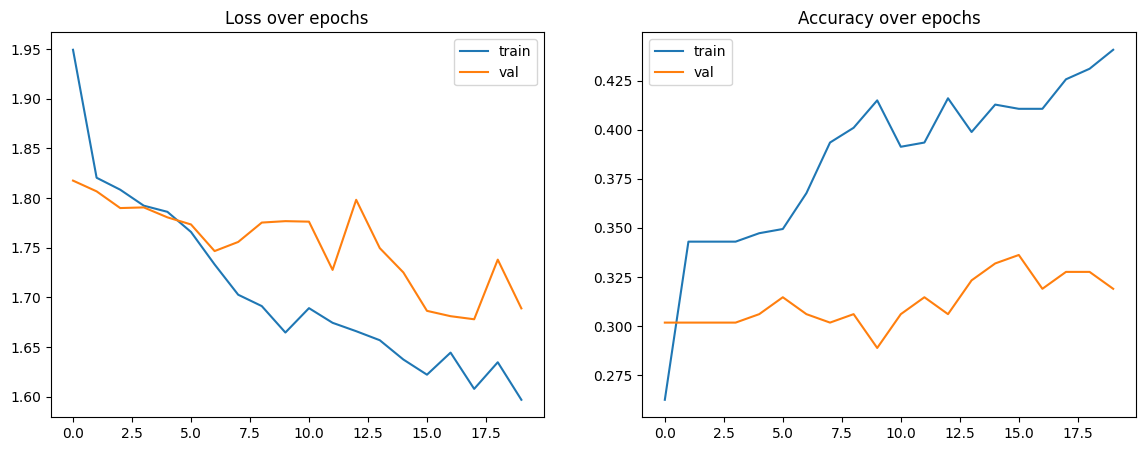

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss over epochs')

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy over epochs')

for a in ax: a.legend()
plt.show()

### Evaluate on Test Dataset

In [8]:
loss, accuracy, precision, recall = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.3394 - loss: 1.6510 - precision: 0.4395 - recall: 0.1681
Test Loss: 1.6889
Test Accuracy: 0.3190
Test Precision: 0.4556
Test Recall: 0.1767


### Confusion Matrix & Classification Report

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


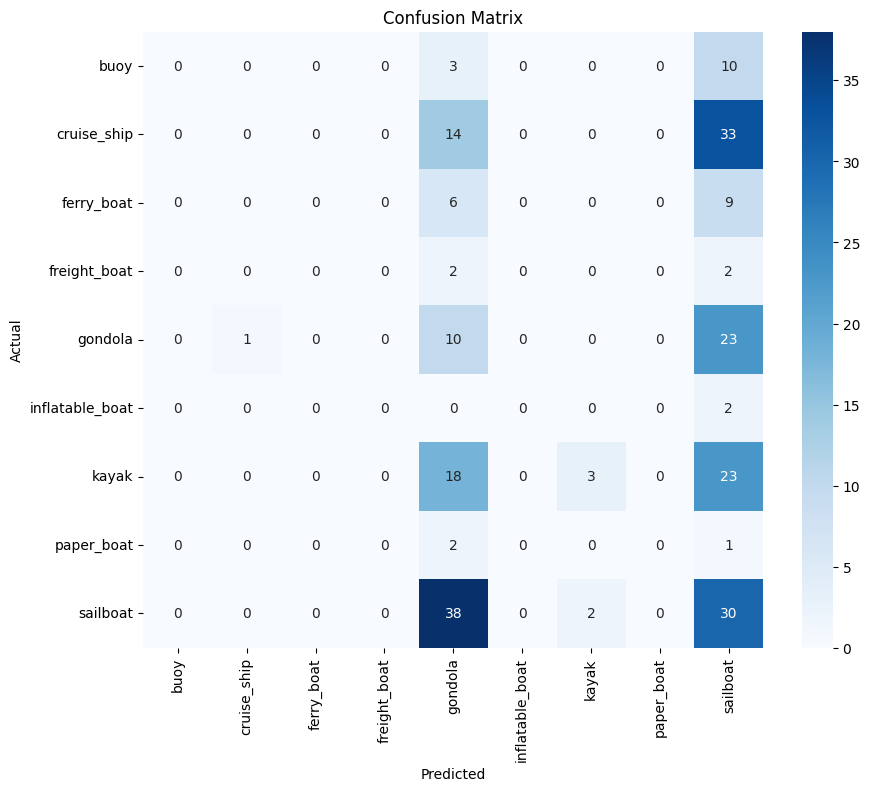

                 precision    recall  f1-score   support

           buoy       0.00      0.00      0.00        13
    cruise_ship       0.00      0.00      0.00        47
     ferry_boat       0.00      0.00      0.00        15
   freight_boat       0.00      0.00      0.00         4
        gondola       0.11      0.29      0.16        34
inflatable_boat       0.00      0.00      0.00         2
          kayak       0.60      0.07      0.12        44
     paper_boat       0.00      0.00      0.00         3
       sailboat       0.23      0.43      0.30        70

       accuracy                           0.19       232
      macro avg       0.10      0.09      0.06       232
   weighted avg       0.20      0.19      0.14       232



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# Collect all true and predicted labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.vstack([model.predict(x) for x, _ in test_ds])
y_true_idx = np.argmax(y_true, axis=1)
y_pred_idx = np.argmax(y_pred, axis=1)

# Confusion matrix heatmap
cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

# Detailed classification metrics
print(classification_report(y_true_idx, y_pred_idx, target_names=class_names))

### MobileNetV2 - Model definition

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt


base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(9, activation='softmax')  # 9 boat classes
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### Compile model

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(9, activation='softmax')  # 9 boat classes
])

### Compile model

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

### Early stopping

In [13]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

### Train model

In [14]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 784ms/step - accuracy: 0.4074 - loss: 1.9423 - precision: 0.5507 - recall: 0.2893 - val_accuracy: 0.7672 - val_loss: 0.9048 - val_precision: 0.8954 - val_recall: 0.5905
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 439ms/step - accuracy: 0.7966 - loss: 0.6732 - precision: 0.8442 - recall: 0.7044 - val_accuracy: 0.7888 - val_loss: 0.6835 - val_precision: 0.8607 - val_recall: 0.7457
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 428ms/step - accuracy: 0.8263 - loss: 0.5735 - precision: 0.8723 - recall: 0.7800 - val_accuracy: 0.8147 - val_loss: 0.6254 - val_precision: 0.8680 - val_recall: 0.7371
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - accuracy: 0.8660 - loss: 0.4265 - precision: 0.9122 - recall: 0.8177 - val_accuracy: 0.8147 - val_loss: 0.5812 - val_precision: 0.8756 - val_recall: 0.7586
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.8746 - loss: 0.3741 - precision: 0.9206 - recall: 0.8210 - val_accuracy: 0.8190 - val_los

### Evaluate model

In [15]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(val_ds)
print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2235 - loss: 5.3385 - precision: 0.2523 - recall: 0.2136
Test Loss: 5.1531, Accuracy: 0.2543, Precision: 0.2944, Recall: 0.2500


### Plotting

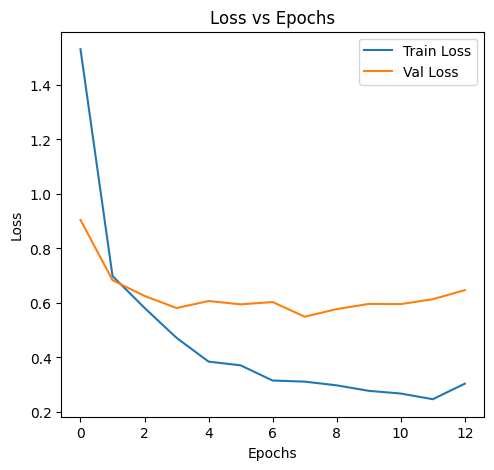

In [16]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()



### Accuracy plot

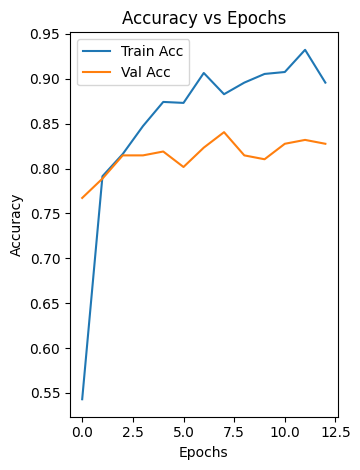

In [17]:

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Compare the results of both models built in steps 1 and 2 and state your observations.

The custom CNN you built may perform reasonably well on dominant boat classes (e.g. ferry_boat, sailboat), but likely struggles on rarer categories like paper_boat or buoy.

The MobileNetV2-based model is expected to be more accurate overall, more robust across all nine boat classes, faster to train, and suitable for on-device deployment given its compact size and high accuracy.